**utils.py**

In [37]:
#from UNet import Unet
#import utils
#import engine
#from learning_rate_range_test import LRTest

import os
import numpy as np
import matplotlib.pyplot as plt

import albumentations as A
import gc
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim

In [38]:
import os
import numpy as np
from PIL import Image
import cv2

def read_valid_pairs(datadir, labeldir, H=512, W=512):
    """
    Load real image-mask pairs.
    Return 2 matrixes : images, mask GT.
    """
    # List available mask
    mask_files = os.listdir(labeldir)
    
    img_list = []
    mask_list = []
    
    for mask_file in mask_files:
        # Extract id of the mask (ex: "man_seg002.png" -> "002")
        # 
        if not mask_file.endswith('.png'):
            continue
            
        # Extract number (3 digits)
        import re
        match = re.search(r'man_seg(\d{3})\.png', mask_file)
        if not match:
            continue
            
        img_num = match.group(1)  # "002", "005", etc.
        
        # Construct the of the corresponding image
        # Images names"t002.png" ?
        #
        img_name = f"t{img_num}.png"  # Exemple : t002.png
        img_path = os.path.join(datadir, img_name)
        
        # verify existance of image
        if not os.path.exists(img_path):
            # Try another format if needed
            img_name = f"image_{int(img_num)}.png"  
            img_path = os.path.join(datadir, img_name)
            if not os.path.exists(img_path):
                print(f"Image non trouvée pour le masque {mask_file}")
                continue
        
        # Load image
        image = np.array(Image.open(img_path))
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)  # Gray
        
        # resize image
        if image.shape[0] != H or image.shape[1] != W:
            image = cv2.resize(image, (W, H))
        
        # Loadmask
        mask = cv2.imread(os.path.join(labeldir, mask_file), cv2.IMREAD_GRAYSCALE)
        _, mask = cv2.threshold(mask, 128, 255, cv2.THRESH_BINARY)
        
        # Resize mask
        if mask.shape[0] != H or mask.shape[1] != W:
            mask = cv2.resize(mask, (W, H))
        
        img_list.append(image)
        mask_list.append(mask)
        print(f"Valid pair : {img_name} <-> {mask_file}")
    
    # Convert to numpy matrix
    img_mtrx = np.array(img_list, dtype=np.uint8)
    mask_mtrx = np.array(mask_list, dtype=np.uint8)
    
    # format (N, H, W) 
    if len(img_mtrx.shape) == 4 and img_mtrx.shape[-1] == 1:
        img_mtrx = img_mtrx.squeeze(-1)
    if len(mask_mtrx.shape) == 4 and mask_mtrx.shape[-1] == 1:
        mask_mtrx = mask_mtrx.squeeze(-1)
    
    print(f"\n Total : {len(img_list)} image-mask pairs loaded.")
    return img_mtrx, mask_mtrx

In [39]:

from collections import defaultdict
import numpy as np
import cv2
import os
from PIL import Image

def readData(datadir, labeldir, H = 512, W = 512):
    img_mtrx  = np.empty(shape = (30, H, W), dtype = np.uint8)
    mask_mtrx = np.empty(shape = (30, H, W))

    # Sort files to keep order
    img_files = sorted(os.listdir(datadir))
    lab_files = sorted(os.listdir(labeldir))

    # Check if we have the same number of files
    assert len(img_files) == len(lab_files), "Differents number of files (NB images different to NB labels"

    # Loop over all image / mask pairs
    for i, (img_file, lab_file) in enumerate(zip(img_files, lab_files)):
            
        # Load image
        image = np.array(Image.open(os.path.join(datadir, img_file)))
        
        # Add channel dimension
        #image = np.expand_dims(image, axis = 0)
        
        # Add to matrix
        img_mtrx[i, :, :] = image 
        
        # Load mask in grayscale (single channel)
        mask = cv2.imread(os.path.join(labeldir, lab_file), cv2.IMREAD_GRAYSCALE)
    
        # Binarise
        _, mask = cv2.threshold(mask, 128, 255, cv2.THRESH_BINARY)
            
        # Add to matrix
        mask_mtrx[i, :, :] = mask 

    return img_mtrx, mask_mtrx

def weight_map(mask, w0, sigma, background_class = 0):
    
    # Fix mask datatype (should be unsigned 8 bit)
    if mask.dtype != 'uint8': 
        mask = mask.astype('uint8')
    
    # Weight values to balance classs frequencies
    wc = _class_weights(mask)
    
    # Assign a different label to each connected region of the image
    _, regions = cv2.connectedComponents(mask)
    
    # Get total no. of connected regions in the image and sort them excluding background
    region_ids = sorted(np.unique(regions))
    region_ids = [region_id for region_id in region_ids if region_id != background_class]
        
    if len(region_ids) > 1: # More than one connected regions

        # Initialise distance matrix (dimensions: H x W x no.regions)
        distances = np.zeros((mask.shape[0], mask.shape[1], len(region_ids)))

        # For each region
        for i, region_id in enumerate(region_ids):

            # Mask all pixels belonging to a different region
            m = (regions != region_id).astype(np.uint8)# * 255
        
            # Compute Euclidean distance for all pixels belongind to a different region
            distances[:, :, i] = cv2.distanceTransform(m, distanceType = cv2.DIST_L2, maskSize = 0)

        # Sort distances w.r.t region for every pixel
        distances = np.sort(distances, axis = 2)

        # Grab distance to the border of nearest region
        d1, d2 = distances[:, :, 0], distances[:, :, 1]

        # Compute RHS of weight map and mask background pixels
        w = w0 * np.exp(-1 / (2 * sigma ** 2)  * (d1 + d2) ** 2) * (regions == background_class)

    else: # Only a single region present in the image
        w = np.zeros_like(mask)

    # Instantiate a matrix to hold class weights
    wc_x = np.zeros_like(mask)
    
    # Compute class weights for each pixel class (background, etc.)
    for pixel_class, weight in wc.items():
    
        wc_x[mask == pixel_class] = weight
    
    # Add them to the weight map
    w = w + wc_x
    
    return w

def _class_weights(mask):
    ''' Create a dictionary containing the classes in a mask,
        and their corresponding weights to balance their occurence
    '''
    
    wc = defaultdict()

    # Grab classes and their corresponding counts
    unique, counts = np.unique(mask, return_counts = True)

    # Convert counts to frequencies
    counts = counts / np.prod(mask.shape)

    # Get max. counts
    max_count = max(counts)

    for val, count in zip(unique, counts):
        wc[val] = max_count / count
    
    return wc

In [40]:
import torch
from torch.utils.data import Dataset
#from utils import weight_map
from torch import nn
import numpy as np


def train(model, optimizer, dataloader, criterion, effective_batch_size, p_bar = None):
    ''' Training '''
    
    model.train()
    optimizer.zero_grad()
    running_loss = 0
    
    for batch_id, (X, y, weights) in enumerate(dataloader):
        
        if p_bar is not None: 
            p_bar.set_description_str(f'Batch {batch_id + 1}')
            
        # Forward
        y_hat = model(X)
        
        # Compute loss
        loss = criterion(y, y_hat, weights) / effective_batch_size
        running_loss += loss.item()
        loss.backward()
        
        # Backprop
        if ( (batch_id + 1) % effective_batch_size == 0 ) or ( (batch_id + 1) == len(dataloader) ):
            optimizer.step()
            optimizer.zero_grad()
        
        # Update progress bar
        if p_bar is not None:
            p_bar.set_postfix(loss = loss.item())
            p_bar.update(1)
    
    # Compute average loss
    running_loss = running_loss /  len(dataloader) * effective_batch_size
        
    return running_loss


def validation(model, dataloader, criterion):
    ''' Validation '''
    
    # Validation
    model.eval()
    running_loss = 0
    
    with torch.no_grad():
        for X, y, weights in dataloader:

            # Forward
            y_hat = model(X)

            # Compute loss
            loss = criterion(y, y_hat, weights)
            running_loss += loss.item()

    # Compute average loss
    running_loss /= len(dataloader)
    
    return running_loss


class EarlyStopping(object):
    '''Early Stopping'''
    
    def __init__(self, patience, fname):
        self.patience  = patience
        self.best_loss = np.Inf
        self.counter   = 0
        self.filename  = fname
        
    def __call__(self, epoch, loss, optimizer, model):
        
        if loss < self.best_loss:
            self.counter = 0
            self.best_loss = loss
            
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss':                 loss,
            }, self.filename)
            
        else:
            self.counter += 1
        
        return self.counter == self.patience


class WeightedBCEWithLogitsLoss(nn.Module):
    ''' Pixel-wise weighted BCEWithLogitsLoss'''
    
    def __init__(self, batch_size):
        
        super().__init__()
        self.batch_size = batch_size
        self.unw_loss = nn.BCEWithLogitsLoss(reduction = 'none')
    
    def __call__(self, true, predicted, weights):
        
        # Compute weighted loss
        loss = self.unw_loss(predicted, true) * weights
        
        # Sum over all channels
        loss = loss.sum(dim = 1)
        
        # Flatten and rescale so that loss is approx. in the same interval
        loss = loss.view(self.batch_size, -1) / weights.view(self.batch_size, -1)
        
        # Average over mini-batch
        loss = loss.mean()

        return loss
    

class SegmentationDataset(Dataset):
    
    def __init__(self, images, masks, wmap_w0, wmap_sigma, device, transform = None):
        ''' Initialisation function '''
        
        self.images    = images
        self.masks     = masks
        self.transform = transform
        self.device    = device
        
        # Parameters for weight map calculation
        self.w0    = wmap_w0
        self.sigma = wmap_sigma

    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        ''' Preprocess and return image, mask, and weight map '''
        
        image = self.images[idx, :, :]
        mask  = self.masks[idx, :, :]
        
        if self.transform:
            
            # Apply transformations
            aug   = self.transform(image = image, mask  = mask)
            image = aug["image"]
            mask  = aug["mask"]
        
        # Compute weight map
        weights = weight_map(mask = mask, w0 = self.w0, sigma = self.sigma)
        
        # Min-max scale image and mask
        image = self.min_max_scale(image, min_val = 0, max_val = 1)
        mask  = self.min_max_scale(mask,  min_val = 0, max_val = 1)
        
        # Add channel dimensions
        image   = np.expand_dims(image,   axis = 0)
        weights = np.expand_dims(weights, axis = 0)
        mask    = np.expand_dims(mask,    axis = 0)
        
        # Convert to tensors and send to device
        weights = torch.from_numpy(weights).double().to(self.device)
        image   = torch.from_numpy(image).double().to(self.device)
        mask    = torch.from_numpy(mask).double().to(self.device)
        
        # Center crop mask and weights (negative padding = cropping - size defined manually)
        mask    = nn.ZeroPad2d(-94)(mask)
        weights = nn.ZeroPad2d(-94)(weights)
        
        return image, mask, weights
    
    @staticmethod
    def min_max_scale(image, max_val, min_val):
        '''Normalization to range of min, max'''
        
        image_new = (image - np.min(image)) * (max_val - min_val) / (np.max(image) - np.min(image)) + min_val
        return image_new

**U-net network for image segmentation** 

In [41]:
# Source: https://github.com/Miltos-90/UNet_Biomedical_Image_Segmentation/blob/main/UNet.py
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np

class Block(nn.Module):
    ''' One block of Unet.
        Contains 2 repeated 3 x 3 unpadded convolutions, each followed by a ReLU.
    '''
    
    def __init__(self, in_channel, out_channel, kernel_size):
        ''' Initialisation '''

        super().__init__()
        self.conv_1 = nn.Conv2d(in_channel, out_channel, kernel_size)
        self.conv_2 = nn.Conv2d(out_channel, out_channel, kernel_size)
        self.relu   = nn.ReLU()
        
        # Initialise weights on convolutional layers        
        nn.init.normal_(self.conv_1.weight, mean = 0.0, std = self.init_std(in_channel, kernel_size))
        nn.init.normal_(self.conv_2.weight, mean = 0.0, std = self.init_std(out_channel, kernel_size))
    
    
    @staticmethod
    def init_std(channels, kernel_size):
        ''' Computes std for weight initialisation on the convolutional layers'''
        return 2.0 / np.sqrt(channels * kernel_size ** 2)
    
        
    def forward(self, x):
        ''' Forward Phase '''
        
        x = self.conv_1(x)
        x = self.relu(x)
        x = self.conv_2(x)
        x = self.relu(x)
        
        return x


class Encoder(nn.Module):
    ''' Contractive Part of Unet '''
    
    def __init__(self, channels):
        '''Initialisation'''
        
        super().__init__()
        
        # Make block list
        modules = []
        
        for in_channel, out_channel in zip(channels[:-1], channels[1:]):
            block    = Block(in_channel = in_channel, out_channel = out_channel, kernel_size = 3)
            modules.append(block)
        
        self.blocks    = nn.ModuleList(modules = modules)
        self.max_pol   = nn.MaxPool2d(kernel_size = 2, stride = None)
        self.feat_maps = [] # Feature map of each block to be concatenated with the decoder part
    
    def forward(self, x):
        '''Forward phase'''
        
        for layer_no, layer in enumerate(self.blocks):
        
            # Run block
            x = layer(x)
            
            if not self.is_final_layer(layer_no):
                
                # Store feature maps for the decoder
                self.feat_maps.append(x)
                
                # Perform max pooling operation
                x = self.max_pol(x)
        
        return x
    
    def is_final_layer(self, layer_no):
        return layer_no == len(self.blocks) - 1

    
class Decoder(nn.Module):
    ''' Expansive Part of Unet '''
    
    def __init__(self, channels):
        '''Initialisation'''
        
        super().__init__()
        
        # Make module lists
        up_convs = []
        blocks   = []
        for in_channel, out_channel in zip(channels[:-1], channels[1:]):
            
            # 2x2 Upconvolution
            upconv = nn.ConvTranspose2d(in_channel, out_channel, kernel_size = 2, stride = 2)
            up_convs.append(upconv)
            
            # Block (2 convolutions with ReLUs)
            block = Block(in_channel, out_channel, kernel_size = 3)
            blocks.append(block)
    
        # Make modules
        self.upconvs = nn.ModuleList(up_convs)
        self.blocks  = nn.ModuleList(blocks)
        
        
    def forward(self, x, encoded_feat_maps):
        
        for upconv, block in zip(self.upconvs, self.blocks):
            
            # Apply upconvolution
            x = upconv(x)
            
            # Grab corresponding feature map from the encoder
            fts = encoded_feat_maps.pop()

            # Crop it
            fts = self.crop(fts, x.shape[2], x.shape[3])
            
            # Concatenate it to the input
            x = torch.cat([x, fts], dim = 1)
            
            # Perform convs with ReLUs
            x = block(x)
            
        return x
            
    @staticmethod
    def crop(tnsr, new_H, new_W):
        ''' Center crop an input tensor to shape [hew_H, hew_W] '''
        
        # Grab existing size
        _, _, H, W = tnsr.size()

        # Compute one corner of the image
        x1 = int(round( (H - new_H) / 2.))
        y1 = int(round( (W - new_W) / 2.))

        # Compute the other one
        x2 = x1 + new_H
        y2 = y1 + new_W

        return tnsr[:, :, x1:x2, y1:y2]


class Unet(nn.Module):
    ''' Unet class
        As suggested in "U-Net: Convolutional Networks for Biomedical Image Segmentation" (https://arxiv.org/pdf/1505.04597.pdf)
    '''
    
    def __init__(self, channels, no_classes, output_size = None):
        '''Initialisation'''
        
        super().__init__()
        
        self.output_size = output_size
        
        # Initialise encoder
        self.encoder = Encoder(channels)
        
        # Initialise decoder
        dec_channels = list(reversed(channels[1:])) # Flip the channels for the contractive part (and omit the first one)
        self.decoder = Decoder(dec_channels) 
        
        # Initialise final layer
        self.head    = nn.Conv2d(in_channels = channels[1], out_channels = no_classes, kernel_size = 1)
    
    
    def forward(self, x):
        '''Forward Phase'''
        
        x = self.encoder(x)
        x = self.decoder(x, self.encoder.feat_maps)
        x = self.head(x)
        
        # Retain dimensions
        if self.output_size is not None:
            x = F.interpolate(x, self.output_size)
        
        return x
        

**Unet implementation**![](https://datasciencetoday.net/images/unet.png)

Let's make sure that the implementation works. We'll check if the output dimensions of the tensors match the ones mentioned in Figure 1 when using the same architecture and same size inputs

In [42]:
import gc

x   = torch.Tensor(np.random.rand(2, 3, 572, 572))
ch  = [3, 64, 128, 256, 512, 1024]
net = Unet(channels = ch, no_classes = 4)
x   = net(x)
print(f"1 - SHAPE OF x: {x.shape}")

x   = torch.Tensor(np.random.rand(3, 1, 572, 572))
ch  = [1, 64, 128, 256, 512]
net = Unet(channels = ch, no_classes = 2, output_size = (572,572))
x   = net(x)
print(f"2 - SHAPE OF x: {x.shape}")

del x, net
gc.collect();

1 - SHAPE OF x: torch.Size([2, 4, 388, 388])
2 - SHAPE OF x: torch.Size([3, 2, 572, 572])


**Trining on ISIBI 2012 challenge dataset**

In [43]:
datadir_seg = '/kaggle/input/datasets/hamzamohiuddin/isbi-2012-challenge/unmodified-data/train/imgs/'
labeldir_seg = '/kaggle/input/datasets/hamzamohiuddin/isbi-2012-challenge/unmodified-data/train/labels/'

# Channel and image dimensions
C, H, W = 1, 512, 512

img_mtrx, mask_mtrx = readData(datadir_seg, labeldir_seg)

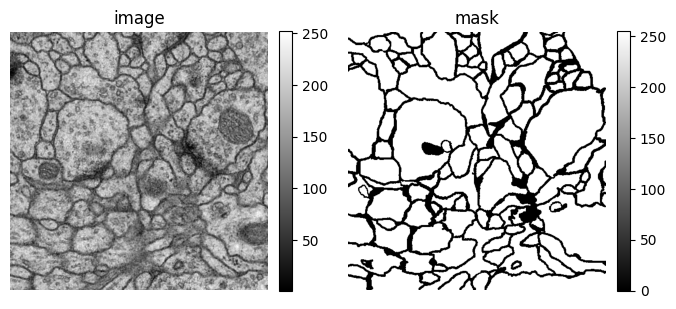

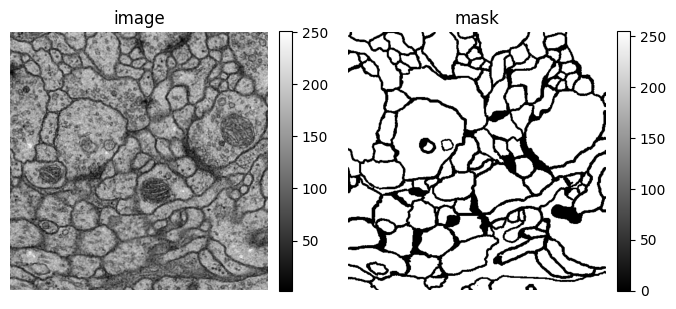

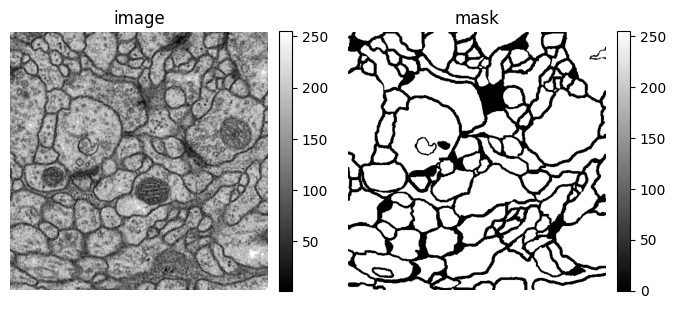

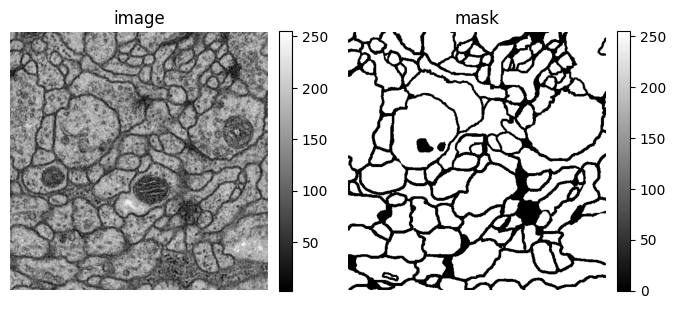

In [44]:
# Plot a few examples
# [1, 5, 10]
for i in range(4):
    fig, ax = plt.subplots(1, 2, figsize = (8, 8))
    
    im = ax[0].imshow(img_mtrx[i, :, :], 'gray')
    plt.colorbar(im, ax = ax[0], fraction = 0.046, pad = 0.04)
    ax[0].axis('off')
    ax[0].set_title('image')

    im = ax[1].imshow(mask_mtrx[i, :, :], 'gray')
    plt.colorbar(im, ax = ax[1], fraction = 0.046, pad = 0.04)
    ax[1].axis('off')
    ax[1].set_title('mask')

**Weight map** 

Authors precompute the weight map for each ground truth segmentation to compensate the different frequency of pixels from a certain class in the training dataset, in order to force the network to learn the small separation borders that they introduce between touching cells. The separation border is computed using morphological operations, and subsequently the weight map is the computed as:

$w(\mathbf{x}) = w_c(\mathbf{x}) + w_0 \exp \left( - \frac{\left[ d_1(x) + d_2(x)\right]^2}{2\sigma^2} \right) $

where $w_c: \Omega \rightarrow \mathbb{R}$ is the weight map to balance the class fequencies, $d_1:\Omega \rightarrow \mathbb{R}$ is the distance to the border of the nearest cell, and  $d_2:\Omega \rightarrow \mathbb{R}$ is the distance to the border of the second nearest cell.

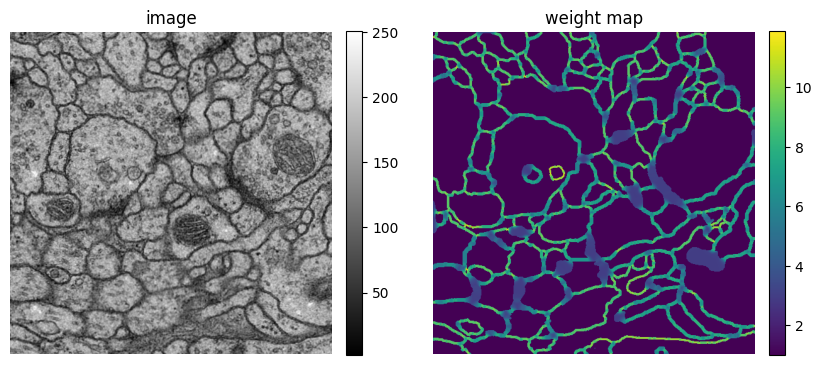

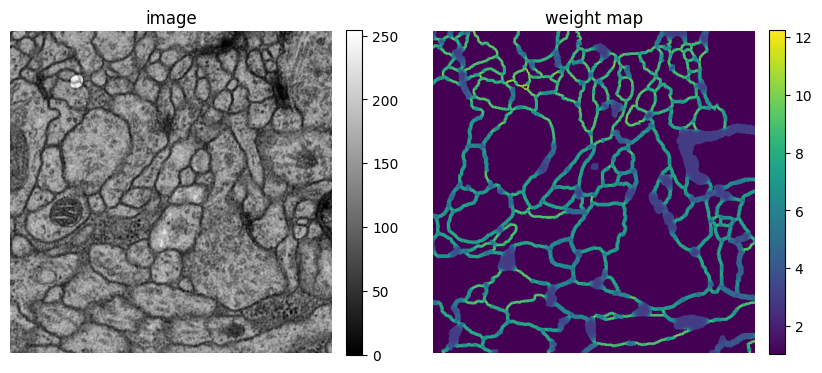

In [45]:
# Parameters used by the authors
w0    = 10
sigma = 5

for i in np.random.randint(0, img_mtrx.shape[0], 2): # Randomly draw 3 images
    
    # Grab image and label map
    mask = mask_mtrx[i, :, :]
    img  = img_mtrx[i, :, :]

    # Compute weight map
    w = weight_map(mask = mask, w0 = w0, sigma = sigma)
    
    # Plot results
    fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 10));

    im = ax[0].imshow(img, 'gray')
    plt.colorbar(im, ax = ax[0], fraction = 0.046, pad = 0.04)
    ax[0].axis('off')
    ax[0].set_title('image')

    im = ax[1].imshow(w)
    plt.colorbar(im, ax = ax[1], fraction = 0.046, pad = 0.04)
    ax[1].axis('off');
    ax[1].set_title('weight map');

**Data augmentation**

In [46]:
# Define augmentation pipelines
p = 0.95
train_transform = A.Compose([
    A.OneOf([
        A.HorizontalFlip(p = p),
        A.VerticalFlip(p = p),
        A.Transpose(p = p),
        A.RandomRotate90(p = p),
        A.ShiftScaleRotate(p = p, shift_limit = 0.0625, scale_limit = 0.1, rotate_limit = 45)
    ], p = 1),
    A.GaussNoise(
        std_range=[0.1, 0.2],
        mean_range=[0, 0],
        per_channel=False
    ),
    A.MultiplicativeNoise(p = p, multiplier=(0.9, 1.1), elementwise = True),
    A.ElasticTransform(p = p, alpha = 300, sigma = 5, approximate = True),
    A.RandomBrightnessContrast(p = p, brightness_limit = 0.15, contrast_limit = 0.15),
    A.PadIfNeeded(p = 1, min_height = 128, min_width = 128, border_mode = cv2.BORDER_REFLECT)
])

**Check transformations**

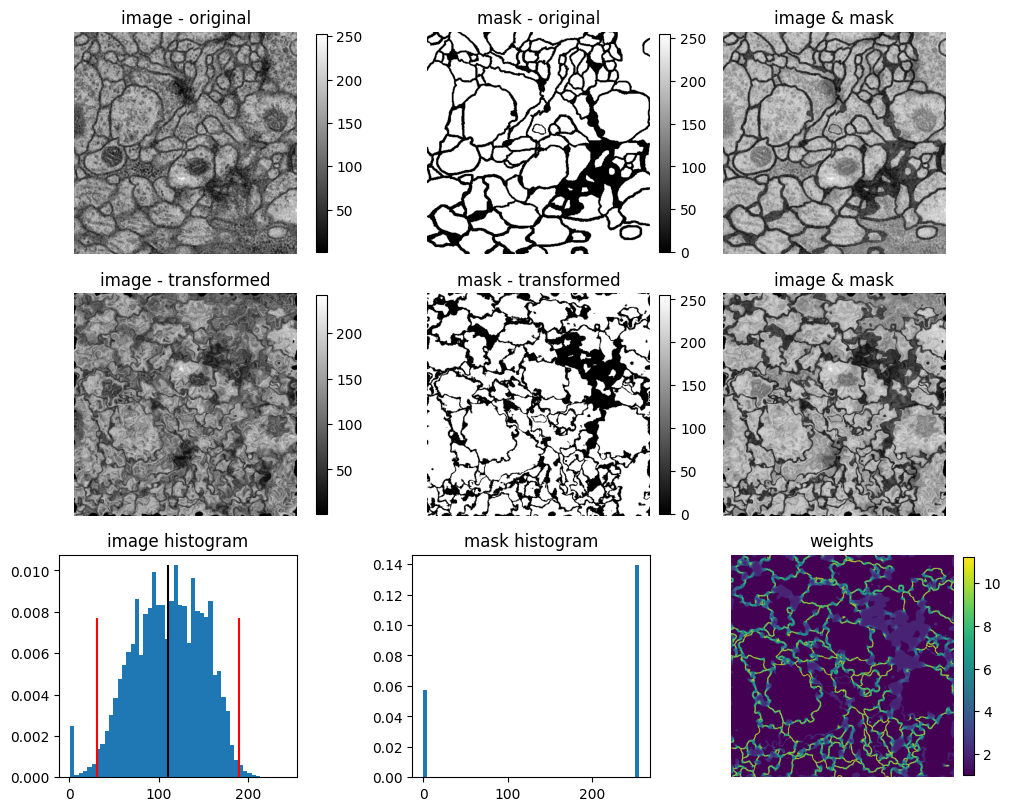

In [47]:
# Parameters recommended by the authors
w0   = 10
sigma = 5

for i in np.random.randint(0, 30, 1): # Randomly draw 1 image
    
    # Grab image and label map
    mask = mask_mtrx[i, :, :]
    img  = img_mtrx[i, :, :]
    
    # Apply transformations
    aug     = train_transform(image = img, mask = mask)
    img_t   = aug["image"]
    mask_t  = aug["mask"]
    
    # Compute weight map
    weights = weight_map(mask = mask_t, w0 = w0, sigma = sigma)

    # Plot
    fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = (10,8), constrained_layout=True)
    
    im = ax[0, 0].imshow(img, 'gray', interpolation = None)
    plt.colorbar(im, ax = ax[0, 0], fraction = 0.046, pad = 0.04)
    ax[0, 0].axis('off');
    ax[0, 0].set_title('image - original')
    
    im = ax[0, 1].imshow(mask, 'gray', interpolation = None)
    plt.colorbar(im, ax = ax[0, 1], fraction = 0.046, pad = 0.04)
    ax[0, 1].axis('off');
    ax[0, 1].set_title('mask - original')
    
    ax[0, 2].imshow(img, 'gray', interpolation = None)
    ax[0, 2].imshow(mask, 'gray', interpolation = None, alpha = 0.3)
    ax[0, 2].axis('off');
    ax[0, 2].set_title('image & mask')
            
    im = ax[1, 0].imshow(img_t, 'gray', interpolation = None)
    plt.colorbar(im, ax = ax[1, 0], fraction = 0.046, pad = 0.04)
    ax[1, 0].axis('off');
    ax[1, 0].set_title('image - transformed')
    
    im = ax[1, 1].imshow(mask_t, 'gray', interpolation = None)
    plt.colorbar(im, ax = ax[1, 1], fraction = 0.046, pad = 0.04)
    ax[1, 1].axis('off');
    ax[1, 1].set_title('mask - transformed')
    
    ax[1, 2].imshow(img_t, 'gray', interpolation = None)
    ax[1, 2].imshow(mask_t, 'gray', interpolation = None, alpha = 0.3)
    ax[1, 2].axis('off');
    ax[1, 2].set_title('image & mask')
    
    counts, _, _ = ax[2, 0].hist(img_t.reshape(-1, 1), bins = 50, density = True);
    ax[2, 0].vlines(img_t.mean(), 0, max(counts), colors='k')
    ax[2, 0].vlines(img_t.mean() + 2 * np.std(img_t), 0, max(counts) * 0.75, colors='r')
    ax[2, 0].vlines(img_t.mean() - 2 * np.std(img_t), 0, max(counts) * 0.75, colors='r')
    ax[2, 0].set_title('image histogram')
    
    ax[2, 1].hist(mask_t.reshape(-1, 1), bins = 50, density = True);
    ax[2, 1].set_title('mask histogram')
    
    im = ax[2, 2].imshow(weights, interpolation = None)
    plt.colorbar(im, ax = ax[2, 2], fraction = 0.046, pad = 0.04)
    ax[2, 2].axis('off');
    ax[2, 2].set_title('weights')

**Learning rate range test**

SGD with a batchsize equal to 1 and momentum equal to 0.99

In [48]:
from torch import optim
from tqdm.notebook import tqdm

class LRTest(object):
    '''
        https://arxiv.org/pdf/1506.01186
        
        This LRTest class implements the Learning Rate Range Test (or LR Finder) 
        technique, popularized by Leslie Smith in the article "Cyclical Learning 
        Rates for Training Neural Networks".

        Goal: Determine the best range of learning rates to train your network. 
        This allows you to automatically find a good learning_rate without having to grope manually.

        -> The idea is simple but powerful:

            * Start from a very small LR (ex: 1e-7)

            * Increase the LR exponentially with each batch

            * Observe the loss: it will first decrease, then stagnate, then explode

            * The LR voucher is located where the loss decreases the fastest
    '''
    def __init__(self, min_lr, max_lr, no_iter, batch_size):
        ''' Initialisation function '''
        
        self.batch_size    = batch_size
        self.no_iter       = no_iter
        self.lr_multiplier = (max_lr / min_lr) ** (1 / (no_iter))
        self.dataiter      = None
        

    # Function to perform the learning rate range test on one experiment
    def __call__(self, dataloader, criterion, optimizer, model):
        ''' LR Range test '''
        
        # Set model to training mode
        model.train()
        
        # Configure scheduler
        scheduler  = optim.lr_scheduler.ExponentialLR(optimizer, gamma = self.lr_multiplier)
        
        # Empty lists to hold results
        loss_arr, lr_arr     = [], []
        
        # Counters' initialisation
        cur_iter, best_loss  = 0, 1e9
        
        with tqdm(total = self.no_iter) as pbar:
            
            while cur_iter < self.no_iter:
                
                # Grab learning rate (before stepping the scheduler)
                lr_arr.append(scheduler.get_lr())
                
                # Train a batch
                cur_loss = self.train_batch(model, criterion, optimizer, scheduler, dataloader)
                
                # Append loss
                loss_arr.append(cur_loss)

                # Check for divergence and exit if needed
                if cur_loss < best_loss: 
                    best_loss = cur_loss

                if cur_loss > 2e2 * best_loss: # Divergence
                    print('Diverged on iteration ' + str(cur_iter) + ' with loss ' + str(cur_loss))
                    break

                # Update progress bar
                pbar.set_postfix(loss = cur_loss)
                pbar.update(1)
                cur_iter += 1

        pbar.close() # Close

        return lr_arr, loss_arr
    
    
    # Return a batch
    def grab_batch(self, dataloader):
        
        # Lazy init
        if self.dataiter is None:
            self.dataiter = iter(dataloader)
        
        # Get next batch
        try:
            X, y, w = next(self.dataiter)
            
        except: # End of dataset -> restart
            
            self.dataiter = iter(dataloader)
            X, y, w  = next(self.dataiter)
        
        return X, y, w
    
    
    # Train batch
    def train_batch(self, model, criterion, optimizer, scheduler, dataloader):

        optimizer.zero_grad()
        
        cur_iter = 0
        run_loss = 0
        while cur_iter < self.batch_size:
        
            # Get sample
            X, y, w = self.grab_batch(dataloader)

            # Predict
            y_hat = model(X)
            
            # Compute normalised gradients
            loss  = criterion(y, y_hat, w) / self.batch_size
            run_loss += loss.item()
            
            # Backprop
            loss.backward()
            
            # Update counter
            cur_iter += 1
        
        # Update
        optimizer.step()
        scheduler.step()

        return run_loss

In [ ]:
act_batch_size = 1 # Can't fit more than one image in GPU!
eff_batch_size = 1 # Efective batch (Gradient accumulation)
device        = 'cuda'
momentum      = 0.99
channels      = [C, 64, 128, 256, 512, 1024]
w0            = 10
sigma         = 5

min_lr  = 1e-6
max_lr  = 3 * 1e-2#10
no_iter = 50

# Configure train test split
np.random.seed(123)
no_img    = img_mtrx.shape[0]
test_idx  = np.random.randint(0, no_img, 3) # Keep 3 images for test set
train_idx = np.setdiff1d(np.arange(0, no_img), test_idx)

# Make model
model     = Unet(channels = channels, no_classes = 1).double().to(device)

# Configure criterion
criterion = WeightedBCEWithLogitsLoss(batch_size = act_batch_size)

# Setup optimiser
optimizer = optim.SGD(model.parameters(), lr = min_lr, momentum = momentum)

# Make dataset
train_set = SegmentationDataset(images = img_mtrx[train_idx, :, :],
                                masks = mask_mtrx[train_idx, :, :],
                                transform = train_transform,
                                device = device, wmap_w0 = w0, wmap_sigma = sigma)

# Make dataloader
train_loader = DataLoader(dataset = train_set, batch_size = act_batch_size,
                          shuffle = True, num_workers = 0, pin_memory = False)

# Run LR range test
lr_test  = LRTest(min_lr = min_lr, max_lr = max_lr, no_iter = no_iter, batch_size = eff_batch_size)
lr, loss = lr_test(train_loader, criterion, optimizer, model)

  0%|          | 0/50 [00:00<?, ?it/s]

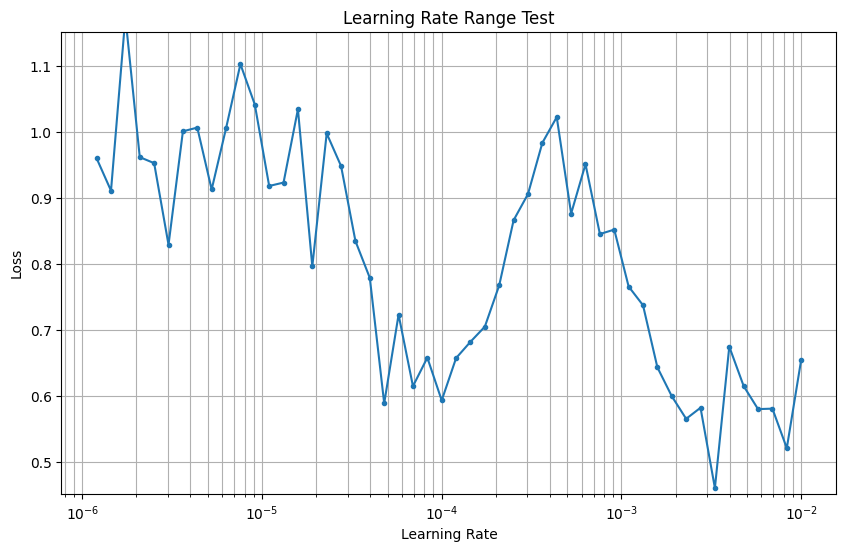

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 6))
plt.semilogx(lr, loss, marker = '.')
plt.ylim(min(loss) * 0.98, min(loss) * 2.5);
plt.title('Learning Rate Range Test')
plt.ylabel('Loss')
plt.xlabel('Learning Rate')
plt.grid(visible = True, which='both', axis='both');

**Training loop**

In [ ]:
epochs         = 1000
learning_rate  = 1e-2
act_batch_size = 1 # Can't fit more than one image in GPU!
eff_batch_size = 1 # Efective batch (Gradient accumulation)
momentum       = 0.99
device         = 'cuda'
channels       = [C, 64, 128, 256, 512, 1024]
w0             = 10
sigma          = 5
model_path     = './model.pt'

# Early stopping
es = engine.EarlyStopping(patience = 100, fname = model_path)

# Make datasets
train_set = engine.SegmentationDataset(images    = img_mtrx[train_idx, :, :],
                                        masks     = mask_mtrx[train_idx, :, :],
                                        transform = train_transform,
                                        device = device, wmap_w0 = w0, wmap_sigma = sigma)

test_set = engine.SegmentationDataset(images    = img_mtrx[test_idx, :, :],
                                        masks     = mask_mtrx[test_idx, :, :],
                                        transform = None,
                                        device = device, wmap_w0 = w0, wmap_sigma = sigma)

# Make dataloaders
train_loader = DataLoader(dataset     = train_set, 
                          batch_size  = act_batch_size, 
                          shuffle     = True,
                          num_workers = 0,     # Change to >0 for performance
                          pin_memory  = False) # Change to true for performance

test_loader  = DataLoader(dataset     = test_set,  
                          batch_size  = act_batch_size,
                          shuffle     = False, 
                          num_workers = 0,     # Change to >0 for performance
                          pin_memory  = False) # Change to true for performance

# Make progress bars
pbar_epoch = tqdm(total = epochs, unit = 'epoch', position = 0, leave = False)
pbar_train = tqdm(total = len(train_loader), unit = 'batch', position = 1, leave = False)

# Make model
model = Unet(channels = channels, no_classes = 1).double().to(device)

# Make optimiser
optimizer = optim.SGD(model.parameters(), lr = learning_rate, momentum = momentum)

# Make loss
criterion = engine.WeightedBCEWithLogitsLoss(batch_size = act_batch_size)

# Load checkpoint (if it exists)
cur_epoch = 0
if os.path.isfile(model_path):
    checkpoint   = torch.load(model_path)
    cur_epoch    = checkpoint['epoch']
    es.best_loss = checkpoint['loss']
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Hold stats for training process
stats = {'epoch': [], 'train_loss': [], 'val_loss': []}

# Training  / validation loop
for epoch in range(cur_epoch, epochs):
    
    # Train / validate
    pbar_epoch.set_description_str(f'Epoch {epoch + 1}')
    train_loss = engine.train(model, optimizer, train_loader, criterion, eff_batch_size, pbar_train)
    val_loss   = engine.validation(model, test_loader, criterion)
    
    # Append stats
    stats['epoch'].append(epoch)
    stats['train_loss'].append(train_loss)
    stats['val_loss'].append(val_loss)
    
    # Early stopping (just saves model if validation loss decreases when: pass)
    if es(epoch, val_loss, optimizer, model): pass
    
    # Update progress bars
    pbar_epoch.set_postfix(train_loss = train_loss, val_loss = val_loss)
    pbar_epoch.update(1)
    pbar_train.reset()

**Training on the HeLa dataset**

HeLa cells on a flat glass

Dr. G. van Cappellen. Erasmus Medical Center, Rotterdam, The Netherlands

Training dataset: https://data.celltrackingchallenge.net/training-datasets/DIC-C2DH-HeLa.zip✱ (37 MB)

Test dataset: https://data.celltrackingchallenge.net/test-datasets/DIC-C2DH-HeLa.zip (41 MB)

Less details
Microscope: Zeiss LSM 510 Meta

Objective lens: Plan-Apochromat 63x/1.4 (oil)

Pixel size (microns): 0.19 x 0.19

Time step (min): 10

In [ ]:
datadir = '/kaggle/input/datasets/cedricniango/dir-01-png/'
labeldir = '/kaggle/input/datasets/cedricniango/01-gt-seg-png/'

datadir2 = '/kaggle/input/datasets/cedricniango/dir-02-png'
labeldir2 = '/kaggle/input/datasets/cedricniango/02-gt-seg-png'

# Channel and image dimensions
C, H, W = 1, 512, 512

img_mtrx1, mask_mtrx1 = read_valid_pairs(datadir, labeldir)
img_mtrx2, mask_mtrx2 = read_valid_pairs(datadir, labeldir)

img_mtrx = np.concat((img_mtrx1, img_mtrx2), axis=0)
mask_mtrx = np.concat((mask_mtrx1, mask_mtrx2), axis=0)

print(f"images mtx: {img_mtrx.shape} , mask mtx: {mask_mtrx.shape}")

In [ ]:
import matplotlib.pyplot as plt

# Plot a few examples
# [1, 5, 10]
for i in range(4):
    fig, ax = plt.subplots(1, 2, figsize = (8, 8))
    
    im = ax[0].imshow(img_mtrx[i, :, :], 'gray')
    plt.colorbar(im, ax = ax[0], fraction = 0.046, pad = 0.04)
    ax[0].axis('off')
    ax[0].set_title('image')

    im = ax[1].imshow(mask_mtrx[i, :, :], 'gray')
    plt.colorbar(im, ax = ax[1], fraction = 0.046, pad = 0.04)
    ax[1].axis('off')
    ax[1].set_title('mask')